## Plot RUL Predictions

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.helpers.visualization import plot_rul_from_dataframe

from experiment_config import DATA_NAME, N_REP,PRED_DIR,ESTIMATION_DIR


'DS01'

## Import test data


In [ ]:
hi_df = pd.read_csv(ESTIMATION_DIR/'data_test.csv')
perform_names = [col for col in hi_df.columns if col not in ['unit','cycle','hs']]
test_units = hi_df['unit'].astype(int).unique().tolist()
onsets = {unit: hi_df[(hi_df['unit']==unit) & (hi_df['hs']==0)]['cycle'].values[0] for unit in test_units}

test_units


[7, 8, 9, 10]

# Load RUL predictions

In [ ]:
df_preds = pd.read_csv(PRED_DIR /f"rul_test_predictions_rep{N_REP}.csv")

PosixPath('experiments/DS01/estimation_thr0.1_q0.01-0.99_filtered_n0.01_s20.0/gamma_onset0.2-0.2/pf_performs/net256x256x128x64x32leaky0.05_emaloss0/pred_mean')

## Plot RUL Predictions

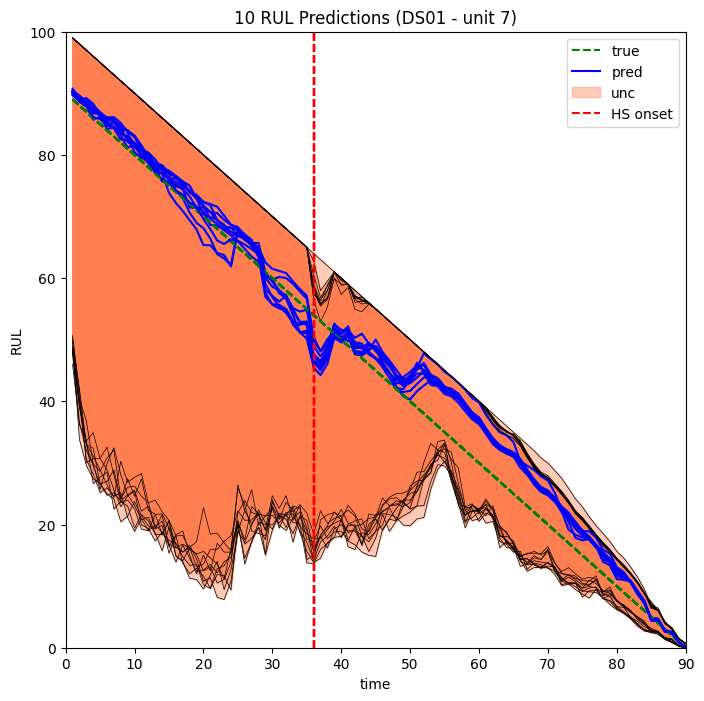

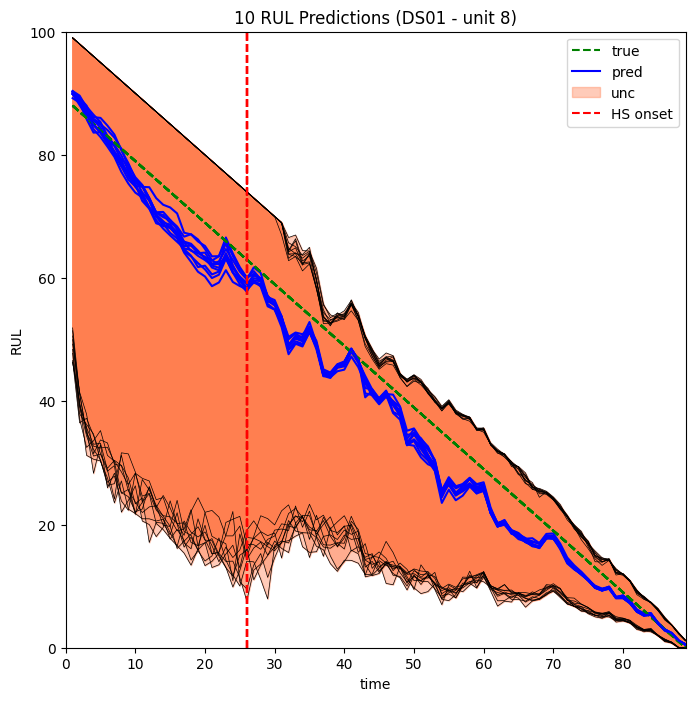

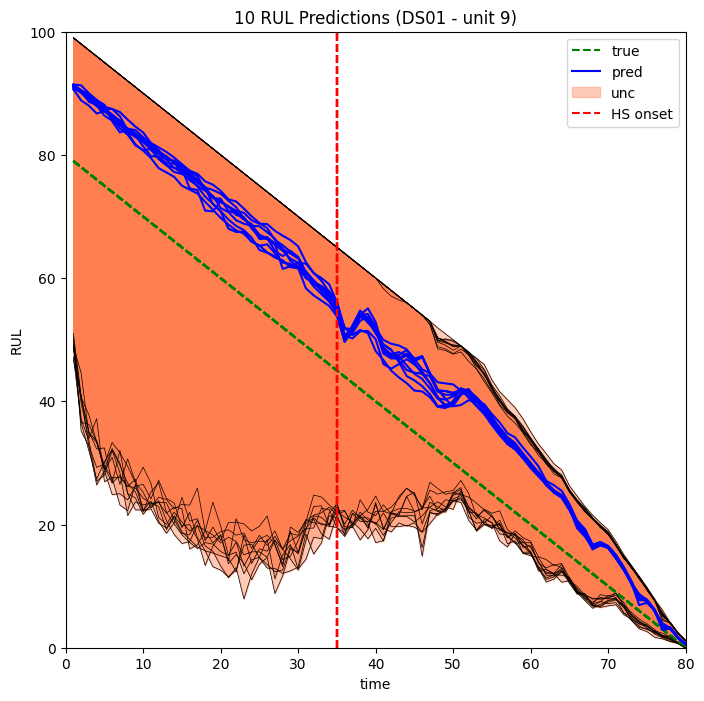

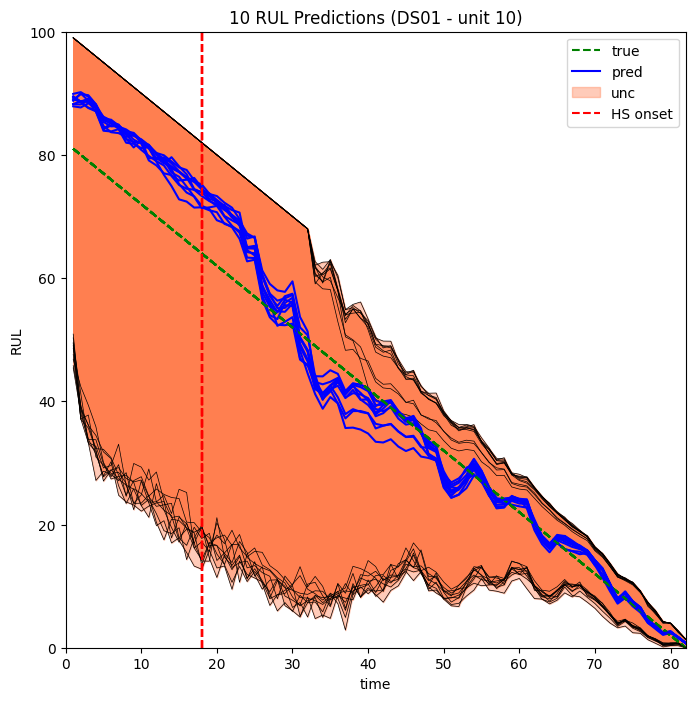

In [ ]:
for unit in test_units:
	fig, ax = plt.subplots(figsize=(8, 8))
	for rep in range(N_REP):
		df = df_preds[(df_preds['unit']==unit) & (df_preds['rep']==rep)]
		eol_time = df['time'].iloc[-1]
		plot_rul_from_dataframe(ax=ax, df=df,t_max=eol_time,
				title=f"{N_REP} RUL Predictions ({DATA_NAME} - unit {unit})", show_legend=False if rep else True)
		ax.vlines(onsets[unit], ymin=0, ymax=100, colors='red', linestyles='dashed', label='HS onset' if rep==0 else None)
	ax.legend()

## inal RUL Mean Prediction

In [6]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()

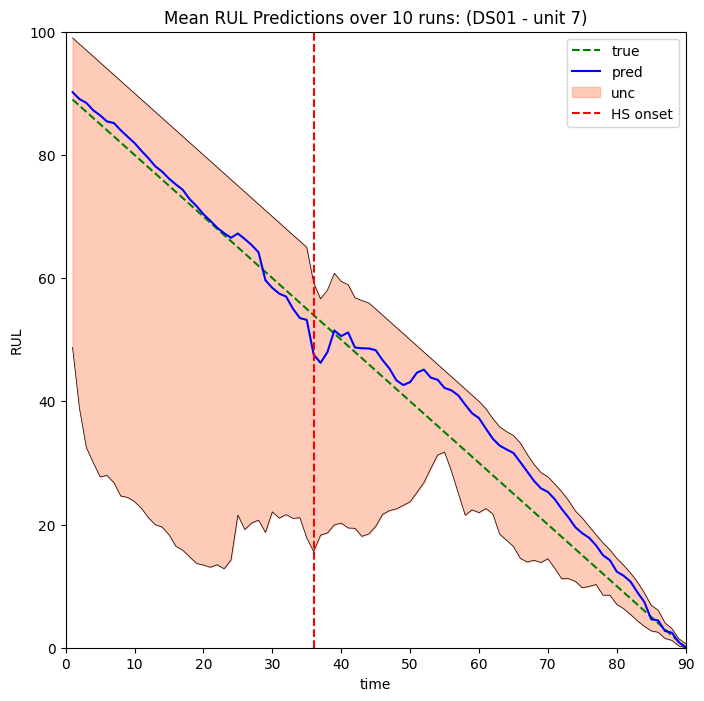

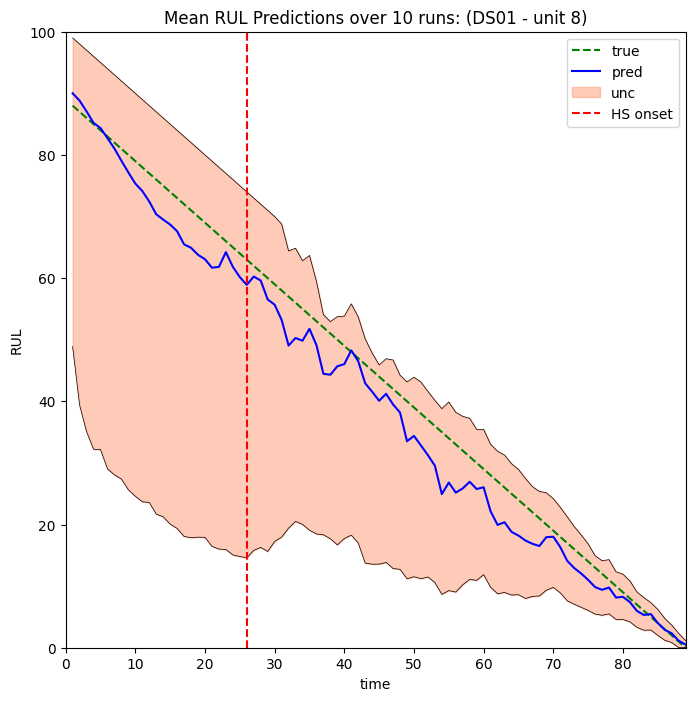

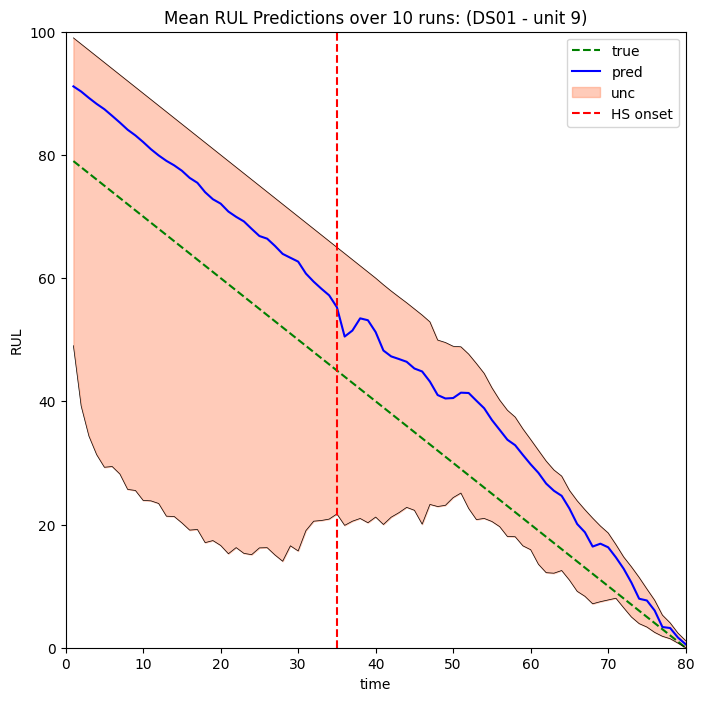

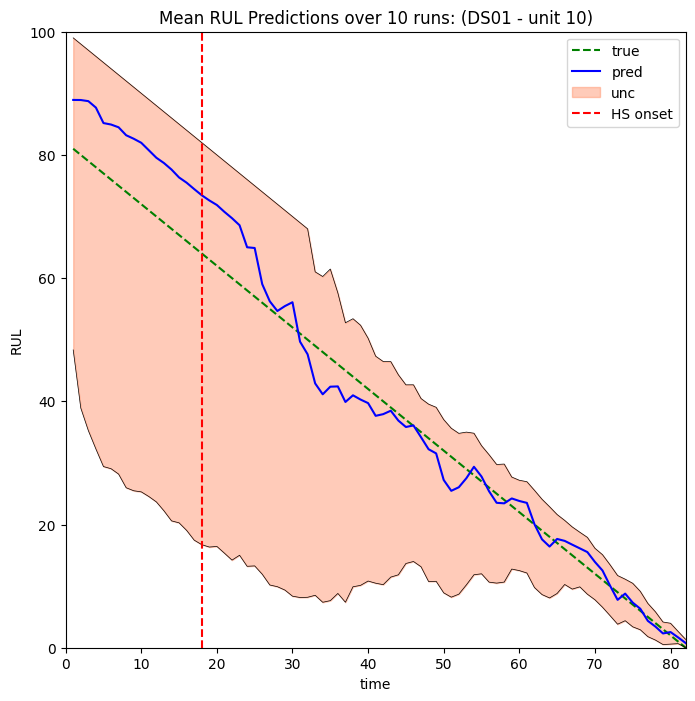

In [ ]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    df = df_preds[df_preds['unit']==unit]
    eol_time = df['time'].iloc[-1]
    plot_rul_from_dataframe(ax=ax, df=df,t_max=eol_time,
            title=f"Mean RUL Predictions over {N_REP} runs: ({DATA_NAME} - unit {unit})", show_legend= True)
    ax.vlines(onsets[unit], ymin=0, ymax=100, colors='red', linestyles='dashed', label='HS onset')
    ax.legend()
    
    # Light red region from HS onset to end of life
    # ax.axvspan(
    #     0,
    #     eol_time,
    #     color='grey',
    #     alpha=0.18,  # transparency (small = lighter)
    # )
 